### PV Secondary Target Selection

## sga_semimajor_grid
### Method to create the secondary targeting file for the intermediate points on the semi-major axis of large galaxies (from the SGA) in the BGS sample

##### Author: Kelly Douglass (University of Rochester)

See `/project/projectdirs/desi/target/secondary/README` for output data model

### Target classes
1. Mid-points on the major axis
2. Mid-points on the minor axis
3. **Points along the major axis**
4. Points off-axis

In [6]:
from astropy.table import Table, Column
from astropy.io import fits
from astropy import units as u
from astropy.coordinates import SkyCoord

import numpy as np

import matplotlib.pyplot as plt
from matplotlib.projections import get_projection_names

from desiutil.plots import init_sky

## Parameters

In [2]:
OVERRIDE = True
REF_EPOCH = 2015.5

#output_directory = '/project/projectdirs/desi/target/secondary/indata/'
output_directory = ''

## Target catalogs

[Siena Galaxy Atlas](https://www.legacysurvey.org/sga/sga2020/)

In [3]:
# Target catalog file names

# input_directory = '/Users/kellydouglass/Documents/Research/data/SGA/'
input_directory = '/global/cfs/cdirs/cosmo/work/legacysurvey/sga/2025/'

input_filename = input_directory + 'SGA2025-beta-parent-refcat-v1.6.kd.fits'

hdul = fits.open(input_filename)
large_galaxies = hdul[1].data
hdul.close()

## Set second priority: points along the major axis

Note: Galaxy centers should already be BGS targets

### Large galaxies

We target only those galaxies with $D(26) > 1.4'$ (the fiber patrol radius).

In [4]:
max_patrol_radius = 1.4 # arcminutes

lg_SGA = large_galaxies[large_galaxies['diam'] >= 2*max_patrol_radius]

print(len(lg_SGA))

4736


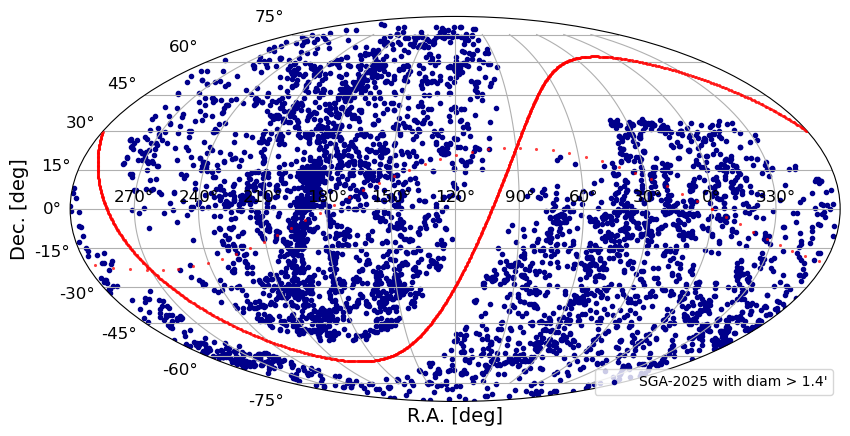

In [7]:
ax = init_sky()

ax.scatter(ax.projection_ra(lg_SGA['ra']), 
           ax.projection_dec(lg_SGA['dec']), 
           marker='.', 
           color='darkblue', 
           label="SGA-2025 with diam > 1.4'")

ax.xaxis.label.set_size(14)
ax.yaxis.label.set_size(14)

plt.legend(loc='lower right')

plt.tick_params(axis='both', which='major', labelsize=12);

## Calculate (ra, dec) of major axis end points

We set fiber target locations along the major axis at a distance of $xR_{26}$, where $x$ varies from 0.2 to 1 in steps of 0.2.

In [6]:
center_ra = lg_SGA['ra']   # degrees
center_dec = lg_SGA['dec'] # degrees

centers = SkyCoord(center_ra*u.deg, center_dec*u.deg)

phi = lg_SGA['pa']*u.deg
r26 = 0.5*lg_SGA['diam']*u.arcmin

In [7]:
x = np.arange(0.2,1.2,0.2).reshape((1,5))

# Distances along the semi-major axis from the center coordinate for our targets
delta_a = np.dot(r26.reshape((len(r26),1)),x)
delta_a = delta_a.T

# Target positions
fiber1 = centers.directional_offset_by(phi, delta_a)
fiber2 = centers.directional_offset_by(phi + 180*u.deg, delta_a)

fiber_ra = np.concatenate((np.ravel(fiber1.ra), np.ravel(fiber2.ra)))
fiber_dec = np.concatenate((np.ravel(fiber1.dec), np.ravel(fiber2.dec)))

In [8]:
print(r26[0])
print(delta_a[:,0])

2.112367630004883 arcmin
[0.42247353 0.84494705 1.26742058 1.6898941  2.11236763] arcmin


### Write target list to file

In [9]:
N_targets = len(fiber_ra)

In [10]:
lg_gal_grid = Table([Column(fiber_ra, name='RA'), 
                     Column(fiber_dec, name='DEC'), 
                     Column(np.zeros(N_targets, dtype='>f4'), name='PMRA'), 
                     Column(np.zeros(N_targets, dtype='>f4'), name='PMDEC'), 
                     Column(REF_EPOCH*np.ones(N_targets, dtype='>f4'), name='REF_EPOCH'),
                     Column(OVERRIDE*np.ones(N_targets, dtype='bool'), name='OVERRIDE')])

In [11]:
lg_gal_grid.write(output_directory + 'sga2025_semimajor_grid.fits', format='fits', overwrite=True)

## Target statistics

In [12]:
print('The number of large galaxies is', len(lg_SGA))
print('The number of targets is', N_targets)

sky_chunk_boolean = np.logical_and.reduce([lg_gal_grid['RA'] > 150, lg_gal_grid['RA'] < 250, 
                                           lg_gal_grid['DEC'] > 0, lg_gal_grid['DEC'] < 50])

num_targets_in_sky_chunk = np.sum(sky_chunk_boolean)

sky_area = 100*50

print('The number of fiber placements in this portion of the sky is', 
      num_targets_in_sky_chunk)
print('The number of fiber placements per square degree is', 
      num_targets_in_sky_chunk/sky_area)

The number of large galaxies is 4736
The number of targets is 47360
The number of fiber placements in this portion of the sky is 9559
The number of fiber placements per square degree is 1.9118
